In [19]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt

STATE_NAMES = ["continuous", "fragmented", "stationary"]
MOUSE_IDS_DUAL = ["99b", "103c", "106b", "107b", "110b"]
MOVEMENT_VARS = ["movement_var2", "movement_var20"]

### Compute STA

In [ ]:
for mv in MOVEMENT_VARS:
    for mouse_id in MOUSE_IDS_DUAL:
        data_dir = INTERIM_DIR / mv / mouse_id
        print(f"Processing {mv} / {mouse_id}")
        print(f"--" * 50)

        if not data_dir.exists():
            print(f"Data dir {data_dir} does not exist, skipping...")
            continue

        sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
        turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
        head_direction = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
        session = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
        nrem = sleep[sleep['state'] == 'nrem']
        order = np.argsort(turn_units['turn_index'].values)

        virtual_hds = []
        states = []
        for i, ep in enumerate(nrem.intersect(session[session['state'] == 'homecage'])):
            decoded = nap.load_file(data_dir / f"{mouse_id}_{i}.npz")
            vh = nap.Tsd(t=decoded.t, d=decoded.values[:, 3])
            virtual_hds.append(vh)
            states_i = nap.TsdFrame(t=decoded.t, d=decoded.values[:, :3], columns=STATE_NAMES)
            states.append(states_i)

        virtual_hds = np.concatenate(virtual_hds)
        states = np.concatenate(states)
        continuous_eps = states['continuous'].threshold(0.5).time_support

        for angles, state in zip([head_direction, np.concatenate(virtual_hds)], ["awake", "nrem"]):
            print(f"Computing STA for {state}...")
            angles = np.deg2rad(angles)
            angles_cart = np.column_stack([np.sin(angles), np.cos(angles)])
            sta = nap.compute_event_triggered_average(angles_cart, turn_units, binsize=1, window=(-500, 500), time_unit='ms')
            sta = nap.TsdFrame(t=sta.t, d=np.rad2deg(np.arctan2(sta[:, :, 0].d, sta[:, :, 1].d)))
            sta.save(data_dir / f"sta_{state}.npz")
        
        angles = np.deg2rad(np.concatenate(virtual_hds))
        angles_cart = np.column_stack([np.sin(angles), np.cos(angles)])
        sta = nap.compute_event_triggered_average(angles_cart, turn_units, binsize=1, window=(-500, 500), time_unit='ms', epochs=continuous_eps)
        sta.save(data_dir / f"sta_nrem_cont.npz")

        print(f"Finished: {mv} / {mouse_id}")
        print(f"--" * 50)



Processing movement_var2 / 99b
----------------------------------------------------------------------------------------------------
Processing movement_var20 / 99b
----------------------------------------------------------------------------------------------------


In [39]:
from nrem_analysis.utils import plot_intervals

eps = states['continuous'].threshold(0.5).time_support
angles = np.deg2rad(virtual_hds)
angles_cart = np.column_stack([np.sin(angles), np.cos(angles)])
angles_cart

Time (s)            0          1
----------  ---------  ---------
5361.0005    0.91707   -0.398726
5361.0015    0.91707   -0.398726
5361.0025    0.91707   -0.398726
5361.0035    0.894946  -0.446175
5361.0045    0.887023  -0.461726
5361.0055    0.894946  -0.446175
5361.0065    0.948331  -0.317282
...
40887.9935  -0.930441   0.366441
40887.9945  -0.930441   0.366441
40887.9955  -0.930441   0.366441
40887.9965  -0.930441   0.366441
40887.9975  -0.936695   0.350147
40887.9985  -0.923859  -0.382734
40887.9995  -0.936695   0.350147
dtype: float64, shape: (11796000, 2)

### Visualize STA

In [ ]:
def plot_sta(sta_awake, sta_nrem, turn_units, mouse_id, save_dir):
    ncols = 5
    nrows = int(np.ceil(sta_awake.shape[1] / ncols))

    f, axs = plt.subplots(
        nrows, ncols,
        figsize=(16, 8),
        sharex=True,
        # sharey=True,
        constrained_layout=True,
        )

    order = np.argsort(turn_units['turn_index'].values)
    axs = axs.flatten()
    for i, idx in enumerate(order):
        uid = turn_units.index[idx].item()
        ax = axs[i]

        zero_idx = np.where(sta_awake.index == 0)[0].item()
        for sta, color in zip([sta_awake, sta_nrem], ['b', 'r']):
            baseline = sta[zero_idx, :]
            sta_norm = sta - baseline
            ax.plot(sta_norm[:, idx], color=color)
        
        ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
        
        ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
        ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)

    f.legend(['Awake', 'NREM'], loc='lower right')
    f.suptitle(f"({mouse_id})")
    plt.savefig(save_dir / f"sta_{mouse_id}.png")
    plt.close(f)

In [ ]:
save_dir = FIGURES_DIR / "sta"
save_dir.mkdir(exist_ok=True)

for mv in ["movement_var2", "movement_var20"]:
    for mouse_id in MOUSE_IDS_DUAL:
        data_dir = INTERIM_DIR  / mv / mouse_id
        if not data_dir.exists():
            continue
        
        turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
        sta_awake = nap.load_file(data_dir / "sta_head_direction.npz")
        sta_nrem = nap.load_file(data_dir / "sta_virtual_hd.npz")

        plot_sta(sta_awake, sta_nrem, turn_units, mouse_id, save_dir)

D:\common_datasets\ucsf\interim\movement_var2\99b
(1001, 17) (1001, 17)
D:\common_datasets\ucsf\interim\movement_var2\100b
D:\common_datasets\ucsf\interim\movement_var2\102b
D:\common_datasets\ucsf\interim\movement_var2\103c
(1001, 7) (1001, 7)
D:\common_datasets\ucsf\interim\movement_var2\106b
(1001, 31) (1001, 31)
D:\common_datasets\ucsf\interim\movement_var2\107b
(1001, 17) (1001, 17)
D:\common_datasets\ucsf\interim\movement_var2\110b
(1001, 7) (1001, 7)
D:\common_datasets\ucsf\interim\movement_var2\111b
D:\common_datasets\ucsf\interim\movement_var20\99b
(1001, 17) (1001, 17)
D:\common_datasets\ucsf\interim\movement_var20\100b
D:\common_datasets\ucsf\interim\movement_var20\102b
D:\common_datasets\ucsf\interim\movement_var20\103c
(1001, 7) (1001, 7)
D:\common_datasets\ucsf\interim\movement_var20\106b
(1001, 31) (1001, 31)
D:\common_datasets\ucsf\interim\movement_var20\107b
(1001, 17) (1001, 17)
D:\common_datasets\ucsf\interim\movement_var20\110b
(1001, 7) (1001, 7)
D:\common_datasets

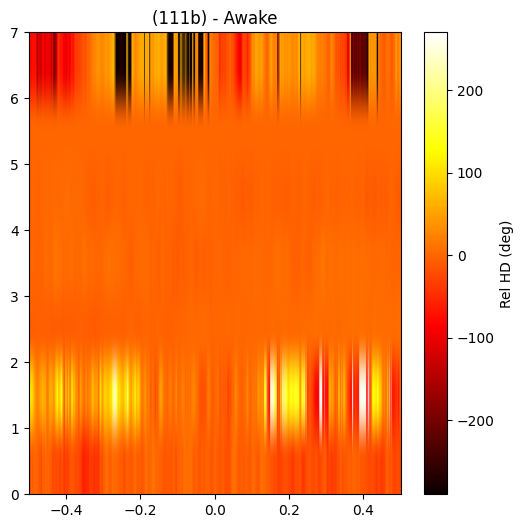

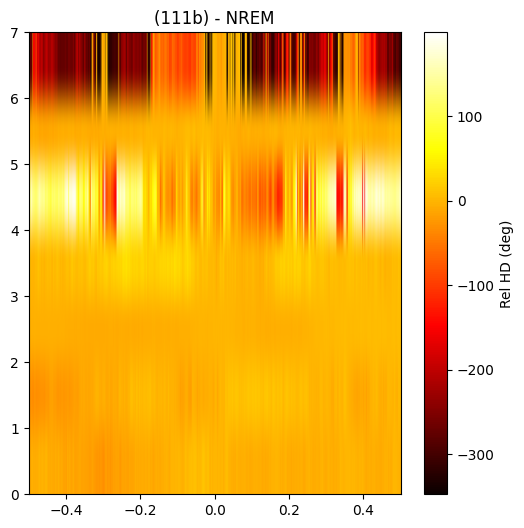

In [13]:
for sta in [sta_awake, sta_nrem]:
    zero_idx = np.where(sta.index == 0)[0].item()
    baseline = sta[zero_idx, :]
    sta_norm = sta - baseline
    plt.figure(figsize=(6, 6))
    im = plt.imshow(sta_norm.d[:, order].T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    plt.colorbar(im, label='Rel HD (deg)')
    plt.title(f"({mouse_id}) - {'Awake' if sta is sta_awake else 'NREM'}")

(5361.0, 5381.0)

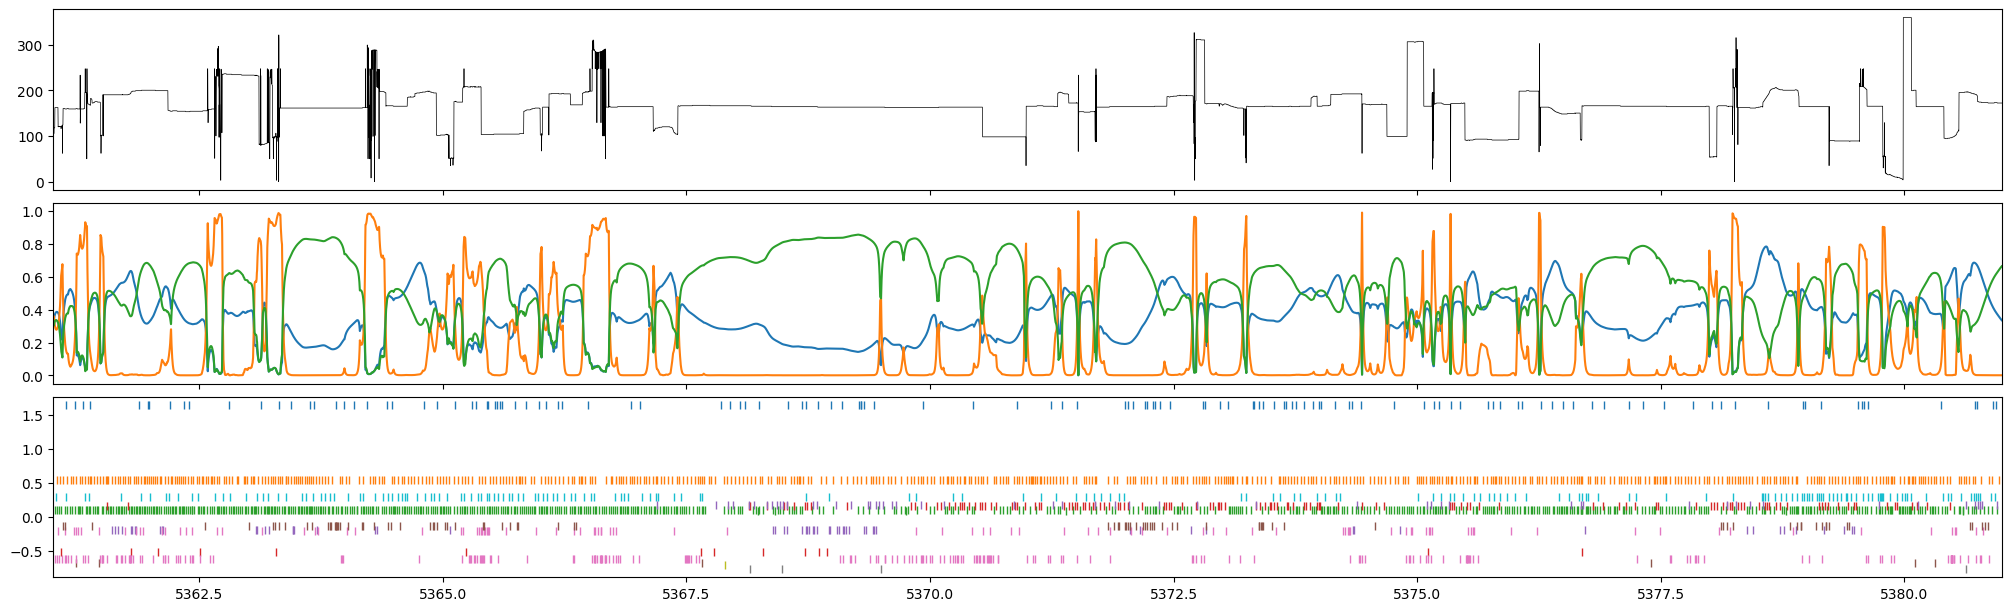

In [52]:
fig, axs = plt.subplots(3, 1, figsize=(20, 6), constrained_layout=True, sharex=True)
axs[0].plot(virtual_hd, color='k', linewidth=0.5)
axs[1].plot(states, label=STATE_NAMES)

for uid in turn_spikes:
    turn_index = turn_spikes['turn_index'][uid].item()
    axs[2].plot(turn_spikes[uid].fillna(turn_index), '|')

axs[0].set_xlim((ep.start, ep.start + 20))